<a href="https://colab.research.google.com/github/AlHartMos/IEU_courses/blob/main/physics_lab/Curve_fitting_with_linear_regression_least_squares_method.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Physics lab: curve fitting with linear regression - least squares method

This notebook is adapted from [1]. Most of your experiments will require you to do curve fitting. You will have a set of data points:

$\begin{array}{c}X_1 \\ X_2 \\ \vdots \\ X_N \end{array} \begin{array}{c}Y_1 \\ Y_2 \\ \vdots \\ Y_N \end{array}$

which could be your measurements results. In most cases, you will have a linear relationship between your data, so you can fit it as:

$Y = b_0 + b_1 X,$

where $b_0$ and $b_1$ are called estimators. Although propagation of errors and obtaining the estimators can become something complicated (you could need quite a bit of statistics), in this course we will work with a linear least square regression.


## An example: the pendulum

One of your first lab experiences is to calculate the acceleration of gravity $g$, by measuring the oscillation period $T$ of a pendulum for different lengths $L$. These quantities are related by:

$T = 2\pi \sqrt{\frac{L}{g}} \;\;\; \Rightarrow \;\;\; T^2 = \frac{4\pi^2}{g} \, L.$

This means, we can fit our data to the relation:

$T^2 = b_0 + b_1 L,$

where $b_1$ will help us estimate $\frac{4\pi^2}{g}$ and $b_0$ should be very close to zero. Hence,

$g = 4\pi^2/b_1$. We will also need to find the uncertainty $\Delta g$, which will be related to the uncertainty $\Delta b_1$ (= standard deviation of $b_1$). Let's use propagation of errors:

$\Delta g= \big |  \frac{\partial g}{\partial b_1} \big | \Delta b_1 = \frac{\partial (4\pi^2/b_1)}{\partial b_1} \big | \Delta b_1=  \frac{4 \pi^2}{b_1^2} \Delta b_1$.

Also, since we will take $T^2$ as our $Y$ variable, we need to calculate the propagation of errors for $T^2$:

$\Delta T^2= \big |  \frac{\partial T^2}{\partial T} \big | \Delta T = 2 T \Delta T$.

This implies that the uncertainty in $T^2$ are nonlinear: data points with a large $T$ will propagate into a larger uncertainty in $T^2$.





## Loading the data

Your measurements should include the data for: $L, \Delta L, T, \Delta T$. Here are some example measurements:

In [ ]:
from scipy import *
from scipy.optimize import curve_fit
import numpy as np

## Input data (generated by simulation with random noise).
L = np.array([0.10, 0.16, 0.22, 0.28, 0.34, 0.40, 0.46, 0.52, 0.58, 0.64])
dL = np.array([0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01, 0.01])
T = np.array([0.71, 0.76, 0.91, 1.00, 1.20, 1.14, 1.44, 1.40, 1.53, 1.58])
dT = np.array([0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05, 0.05])

Since the fit will be with $T^2$, we need to calculate it and also estimate the uncertainty $\Delta T^2$ using our propagation of errors from before:

In [ ]:
Tsq = T**2             # Estimates for T^2
Tsq_error = 2*T*dT     # Errors for T^2, from error propagation rules

We can take a look at how our data looks like already:

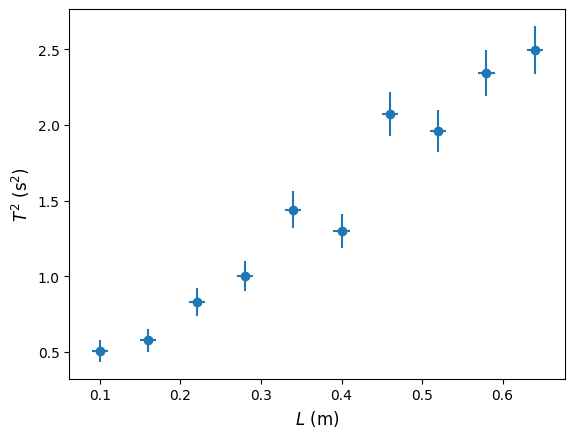

In [ ]:
## Plot the data points, with error bars
import matplotlib.pyplot as plt
## plt.style.use('dark_background') #this puts it with a dark background. You can comment this line.

plt.errorbar(L, Tsq, xerr=dL, yerr=Tsq_error, fmt='o')
plt.xlabel('$L$ (m)', fontsize=12)
plt.ylabel('$T^2$ (s$^2$)', fontsize=12)

plt.show()

## Fitting the data

Now we can define the fit and use it to fit our data:

In [ ]:
## Define an order-1 polynomial function, and use it to fit the data

def f(x, b0, b1): return b0 + b1*x
est, covar = curve_fit(f, L, Tsq)


Once this fit has been done, we can extract the estimators $b_1$ and $b_0$ and their errors.

In [ ]:
## Estimators and their errors:
b0, b1 = est               # Estimates of intercept and slope
db0 = np.sqrt(covar[0,0])     # Standard error of intercept
db1 = np.sqrt(covar[1,1])     # Standard error of slope

print(f"b0 ={b0}") # it is good practice to check that b0 is very close to zero
print(f"b1 ={b1}")

b0 =-0.006057788883900184
b1 =3.940777817269619


With $b_1$ and $\Delta b_1$, we can calculate $g$ and its uncertainty $\Delta g$:



In [ ]:
g = 4*np.pi*np.pi/b1             # Estimate for g (computed from b1)
dg = (g/b1)*db1            # Estimate for standard error of g

print(f"g ={g}")
print (f"dg={dg}")

#we round up to and describe the acceleration of gravity with the appropriate significant figures and its units.
print(f"g = {g:.1f} +/- {dg:.1f} m/s^2")

g =10.017925251038433
dg=0.724616565126874
g = 10.0 +/- 0.7 m/s^2


#Plotting data and fit

Now we can plot both our data and the fit.




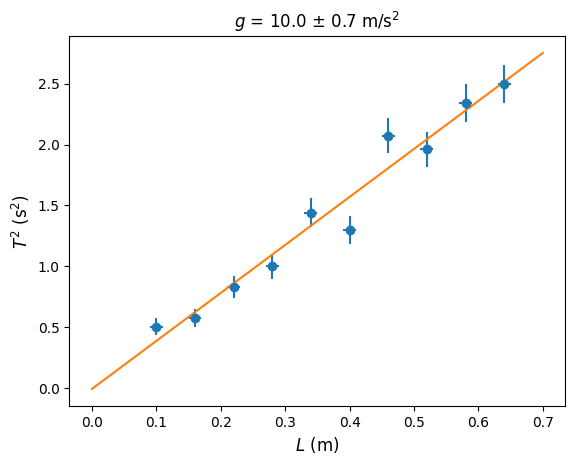

In [ ]:
## Plot the data points, with error bars
import matplotlib.pyplot as plt
## plt.style.use('dark_background') #this puts it with a dark background. You can comment this line.

plt.errorbar(L, Tsq, xerr=dL, yerr=Tsq_error, fmt='o')
plt.xlabel('$L$ (m)', fontsize=12)
plt.ylabel('$T^2$ (s$^2$)', fontsize=12)

# Include the fitted curve in the plot
L2 = np.linspace(0, 0.7, 100)
plt.plot(L2, b0 + b1*L2)

# State fitted value of g in the figure title
plt.title(f"$g$ = {g:.1f} $\pm$ {dg:.1f} m/s$^2$", fontsize=12)
plt.show()

##References

[1] Y.D. Chong. Curve Fitting. Physics Laboratory. Nanyang Technological University.

[2] I. G. Hughes and T. P. A. Hase, Measurements and their uncertainties (Oxford University Press, 2010).
